# K-Means Clustering on Iris Dataset

This notebook performs K-Means clustering on the Iris dataset.

## Objectives:
1. Load the iris dataset and explore its structure
2. Remove non-numeric columns (species labels) for Euclidean distance calculation
3. Apply K-Means with various K values
4. Compare K=3 clusters against actual species labels
5. Evaluate clustering quality using metrics and visualization

## Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, adjusted_rand_score
from sklearn.preprocessing import LabelEncoder

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load and Explore Data

In [24]:
# Load iris dataset
df = pd.read_csv('Unit06 iris.csv')

# Display first few rows
print("First few rows of the dataset:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nSpecies labels: {df['species'].unique()}")
print(f"\nSpecies counts:\n{df['species'].value_counts()}")

First few rows of the dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Dataset shape: (150, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

Species labels: <StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

Species counts:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## Prepare Data for K-Means

Remove the 'Species' column since K-Means requires numeric features for Euclidean distance calculation.

In [25]:
# Separate features and labels
X = df.drop('species', axis=1)  # drop the species column
y_true = df['species']  # save the species column for later evaluation

print(f"Features for clustering: {X.columns.tolist()}")
print(f"\nFeatures shape: {X.shape}")
print(f"\nFeature statistics:\n{X.describe()}")

Features for clustering: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Features shape: (150, 4)

Feature statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


## Find Optimal K
Combine Elbow Method and Silhouette scores.
- Elbow: Narrow down possible K values using SSE
- Silhouette: Choose the K with the best cluster quality amongs those candidates



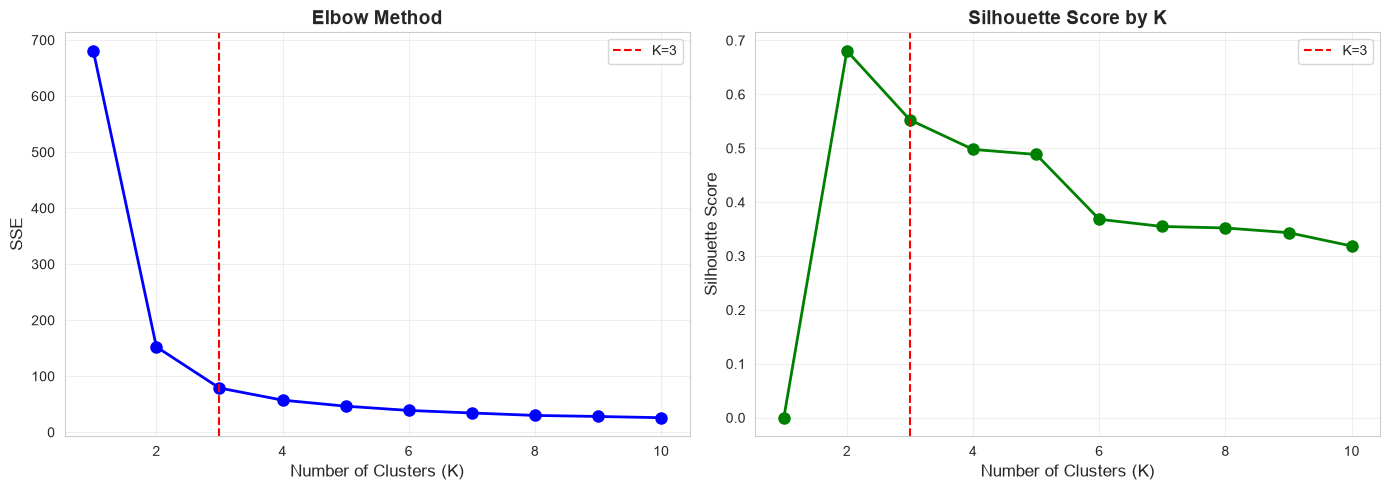

Silhouette scores for different K values:
K=1: 0.0000
K=2: 0.6808
K=3: 0.5526
K=4: 0.4978
K=5: 0.4885
K=6: 0.3682
K=7: 0.3548
K=8: 0.3521
K=9: 0.3434
K=10: 0.3186


In [26]:
sse = []
silhouette_scores = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)
    # Calculate silhouette score only if k > 1. 
    # Silhouette score is not defined for k=1.
    if k > 1:
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))
    else:
        silhouette_scores.append(0)

# Plot elbow curve and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, sse, 'bo-', linewidth=2, markersize=8)
# draw a vertical line at K=3 for reference
axes[0].axvline(x=3, color='r', linestyle='--', label='K=3')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('SSE', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
# draw a vertical line at K=3 for reference
axes[1].axvline(x=3, color='r', linestyle='--', label='K=3')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score by K', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Silhouette scores for different K values:")
for k, score in zip(K_range, silhouette_scores):
    print(f"K={k}: {score:.4f}")

## Apply K-Means with K=3

In [27]:

kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
# Fit the model and predict cluster labels
y_pred = kmeans_3.fit_predict(X)

print(f"K-Means with K=3 Clustering Results:")
print(f"SSE: {kmeans_3.inertia_:.4f}")
print(f"Silhouette Score: {silhouette_score(X, y_pred):.4f}")
print(f"\nCluster sizes:")
unique, counts = np.unique(y_pred, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples")

# Add predictions to dataframe
df['Cluster'] = y_pred

K-Means with K=3 Clustering Results:
SSE: 78.9408
Silhouette Score: 0.5526

Cluster sizes:
Cluster 0: 62 samples
Cluster 1: 50 samples
Cluster 2: 38 samples


# Clustering Evaluation



## PCA Plot

A PCA plot lets you visually verify whether the K-Means clusters correspond to these natural groupings.

Visually we note that:
- Cluster 0 -> Versicolor
- Cluster 1 -> Setosa
- Cluster 2 -> Virginica

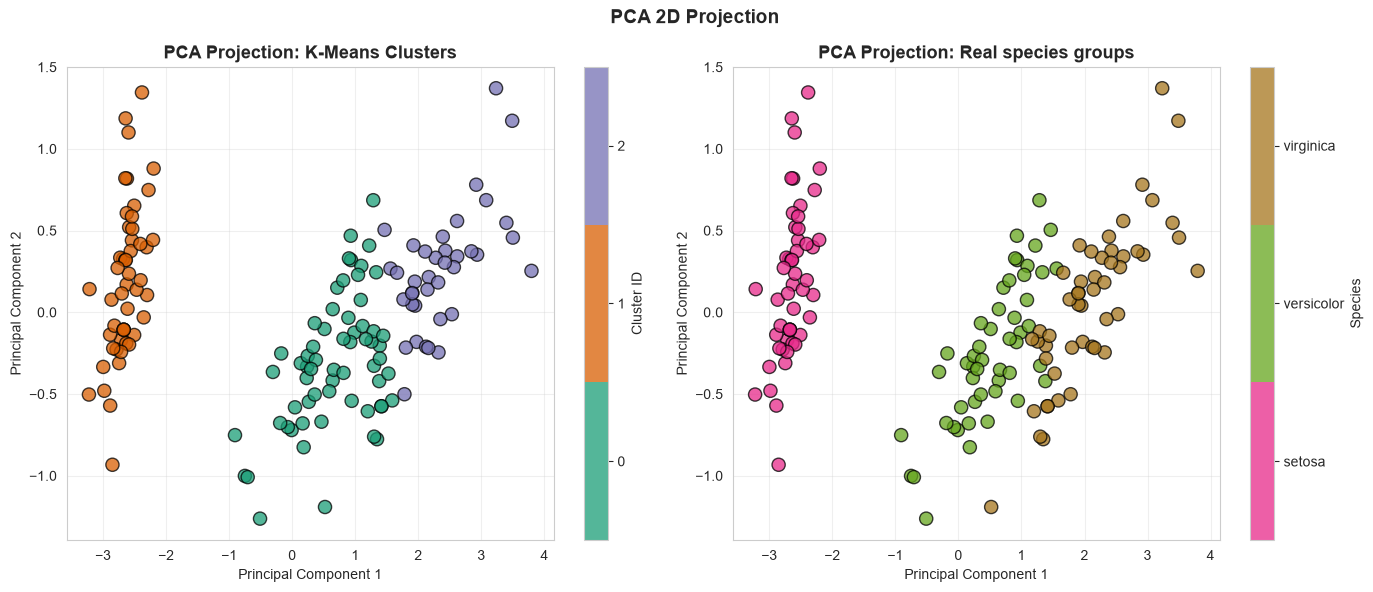

In [28]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import LabelEncoder

# Encode true labels for comparison
label_encoder = LabelEncoder()
y_true_encoded = label_encoder.fit_transform(y_true)


# Project features to 2 principal components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Use two non-overlapping palettes so colors are never repeated between plots
kmeans_cmap = ListedColormap(['#1b9e77', '#d95f02', '#7570b3'])
reference_cmap = ListedColormap(['#e7298a', '#66a61e', '#a6761d'])

# Create side-by-side PCA plots for predicted clusters vs true labels
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: K-Means cluster assignments (palette A)
scatter_kmeans = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_pred,
    cmap=kmeans_cmap,
    vmin=-0.5,
    vmax=2.5,
    s=90,
    alpha=0.75,
    edgecolors='k'
)
axes[0].set_title('PCA Projection: K-Means Clusters', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter_kmeans, ax=axes[0], label='Cluster ID', ticks=[0, 1, 2])

# Right: Reference labels with species names on the colorbar
scatter_true = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_true_encoded,
    cmap=reference_cmap,
    vmin=-0.5,
    vmax=2.5,
    s=90,
    alpha=0.75,
    edgecolors='k'
)
axes[1].set_title('PCA Projection: Real species groups', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')
axes[1].grid(True, alpha=0.3)
cbar_right = plt.colorbar(scatter_true, ax=axes[1], ticks=[0, 1, 2])
cbar_right.set_label('Species')
cbar_right.set_ticklabels(label_encoder.classes_)

plt.suptitle('PCA 2D Projection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Confusion Matrix

In [29]:
cm = confusion_matrix(y_true_encoded, y_pred)
print("Confusion Matrix (True Labels vs Predicted Clusters):")
print(cm)
print(f"\nTrue labels: {label_encoder.classes_.tolist()}")
print(f"Cluster assignments: {np.arange(3).tolist()}")
print(f"Features used: {X.columns.tolist()}")

Confusion Matrix (True Labels vs Predicted Clusters):
[[ 0 50  0]
 [48  0  2]
 [14  0 36]]

True labels: ['setosa', 'versicolor', 'virginica']
Cluster assignments: [0, 1, 2]
Features used: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
